<h1 style="text-align: center; font-weight: bold;">
Évaluation intermédiaire - Python pour la data science
</h1>



## **groupe : 4A**
**Amira BARHOUMI**  
**Yassine MELLOUL**  
**Antoine FOUCART**



<div style="text-align: right;font-weight: bold;">
Chargé de TD : Julien PRAMIL
</div>


# **Importation des données :**

In [23]:
import pandas as pd

df = pd.read_csv(
    'https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb'
)
df.head()

/tmp/ipykernel_8502/1661597950.py:3: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix
0,01,Ain,1,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3
1,01,Ain,2,L'Abergement-de-Varey,Nathalie,ARTHAUD,2
2,01,Ain,4,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38
3,01,Ain,5,Ambérieux-en-Dombes,Nathalie,ARTHAUD,8
4,01,Ain,6,Ambléon,Nathalie,ARTHAUD,0


 ## **1. Explorations générales**
 ### *Question 1 - Création des variables :*

In [24]:
df["code_commune"] = (
    df["code_departement"].astype(str)
    + df["code_commune"].astype(str).str.zfill(3)
)

# création colonne candidat
df["candidat"] = df["prenom"] + " " + df["nom"]
df.head(5)

,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix,candidat
0,01,Ain,01001,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3,Nathalie ARTHAUD
1,01,Ain,01002,L'Abergement-de-Varey,Nathalie,ARTHAUD,2,Nathalie ARTHAUD
2,01,Ain,01004,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38,Nathalie ARTHAUD
3,01,Ain,01005,Ambérieux-en-Dombes,Nathalie,ARTHAUD,8,Nathalie ARTHAUD
4,01,Ain,01006,Ambléon,Nathalie,ARTHAUD,0,Nathalie ARTHAUD


In [25]:
#test : 
df[df["libelle_commune"].str.contains("Montrouge", na=False)][["code_departement", "code_commune"]].head(3)

,code_departement,code_commune
34535,92,92049
69780,92,92049
105025,92,92049


### *Question 2 - Nombre de candidats*



In [26]:

df["candidat"].unique()
candidats = df["candidat"].dropna().nunique()
f"En 2022, il y avait {candidats} candidats à l'élection présidentielle."

"En 2022, il y avait 12 candidats à l'élection présidentielle."

### *Question 3 - Scores nationaux*

In [27]:
scores_nationaux = df.groupby("candidat")["voix"].sum().reset_index()
scores_nationaux.columns = ["candidat", "votes"]

total_exprime = scores_nationaux["votes"].sum()

scores_nationaux["score"] = (scores_nationaux["votes"] / total_exprime * 100).round(2)

scores_nationaux.sort_values("votes", ascending=False).reset_index(drop=True)

,candidat,votes,score
0,Emmanuel MACRON,9783058,27.85
1,Marine LE PEN,8133828,23.15
2,Jean-Luc MÉLENCHON,7712520,21.95
3,Éric ZEMMOUR,2485226,7.07
4,Valérie PÉCRESSE,1679001,4.78
5,Yannick JADOT,1627853,4.63
6,Jean LASSALLE,1101387,3.13
7,Fabien ROUSSEL,802422,2.28
8,Nicolas DUPONT-AIGNAN,725176,2.06
9,Anne HIDALGO,616478,1.75


Mise en forme du tableau : 

In [28]:
from great_tables import GT
scores_affichage = scores_nationaux.sort_values("votes", ascending=False).reset_index(drop=True)
scores_affichage["score"] = scores_affichage["score"].apply(lambda x: f"{x:.2f}%")
(
    GT(scores_affichage)
    .tab_header(
        title="Elections présidentielles ",
        subtitle="Résultats du premier tour (📅 10 avril 2022)"
    )
    .cols_label(
        candidat="Candidat",
        votes="Nombre votes (total)",
        score="Score (% votes exprimés)"
    )
)

GT(_tbl_data=                 candidat    votes   score
0         Emmanuel MACRON  9783058  27.85%
1           Marine LE PEN  8133828  23.15%
2      Jean-Luc MÉLENCHON  7712520  21.95%
3            Éric ZEMMOUR  2485226   7.07%
4        Valérie PÉCRESSE  1679001   4.78%
5           Yannick JADOT  1627853   4.63%
6           Jean LASSALLE  1101387   3.13%
7          Fabien ROUSSEL   802422   2.28%
8   Nicolas DUPONT-AIGNAN   725176   2.06%
9            Anne HIDALGO   616478   1.75%
10        Philippe POUTOU   268904   0.77%
11       Nathalie ARTHAUD   197094   0.56%, _body=<great_tables._gt_data.Body object at 0x7ffa8ed8caf0>, _boxhead=Boxhead([ColInfo(var='candidat', type=<ColInfoTypeEnum.default: 1>, column_label='Candidat', column_align='left', column_width=None), ColInfo(var='votes', type=<ColInfoTypeEnum.default: 1>, column_label='Nombre votes (total)', column_align='right', column_width=None), ColInfo(var='score', type=<ColInfoTypeEnum.default: 1>, column_label='Score (% votes exprimés)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7ffa8f79c410>, _spanners=Spanners([]), _heading=Heading(title='Elections présidentielles ', subtitle='Résultats du premier tour (📅 10 avril 2022)', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7ffa8f7b7820>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7ffa8f1470b0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7ffa8e64f110>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', t

## **2. Comparaison départements / nationale**
### *Question 4 - Scores par département*

In [29]:
score_departements = (
    df
    .groupby(["code_departement", "candidat"])["voix"]
    .sum()
    .reset_index()
)

score_departements.columns = ["code_departement", "candidat", "votes"]

# total des votes exprimés par département
total_dep = (
    score_departements
    .groupby("code_departement")["votes"]
    .sum()
    .reset_index(name="total_votes")
)

# merge
score_departements = score_departements.merge(total_dep, on="code_departement")

# score
score_departements["score"] = (
    score_departements["votes"] / score_departements["total_votes"] * 100
).round(2)

# tri 
score_departements = score_departements.sort_values(
    ["code_departement", "votes"],
    ascending=[True, False]
).reset_index(drop=True)

score_departements = score_departements.drop(columns="total_votes")

score_departements[score_departements["code_departement"] == "11"]

,code_departement,candidat,votes,score
120,11,Marine LE PEN,64027,30.14
121,11,Emmanuel MACRON,43104,20.29
122,11,Jean-Luc MÉLENCHON,42039,19.79
123,11,Éric ZEMMOUR,18434,8.68
124,11,Jean LASSALLE,12382,5.83
125,11,Valérie PÉCRESSE,7350,3.46
126,11,Yannick JADOT,6322,2.98
127,11,Anne HIDALGO,6166,2.90
128,11,Fabien ROUSSEL,5622,2.65
129,11,Nicolas DUPONT-AIGNAN,4206,1.98


### *Question 5 - Comparaison avec le niveau national*

In [30]:
scores_nationaux = scores_nationaux.rename(columns={
    "votes": "votes_national",
    "score": "score_national"
})

score_departements = score_departements.rename(columns={
    "votes": "votes_departement"
})

score_departements = score_departements.merge(
    scores_nationaux,
    on="candidat"
)

score_departements[
    score_departements["code_departement"] == "11"
].sort_values("score", ascending=False)

score_departements[
    score_departements["code_departement"] == "11"
].sort_values("score", ascending=False)

,code_departement,candidat,votes_departement,score,votes_national,score_national
120,11,Marine LE PEN,64027,30.14,8133828,23.15
121,11,Emmanuel MACRON,43104,20.29,9783058,27.85
122,11,Jean-Luc MÉLENCHON,42039,19.79,7712520,21.95
123,11,Éric ZEMMOUR,18434,8.68,2485226,7.07
124,11,Jean LASSALLE,12382,5.83,1101387,3.13
125,11,Valérie PÉCRESSE,7350,3.46,1679001,4.78
126,11,Yannick JADOT,6322,2.98,1627853,4.63
127,11,Anne HIDALGO,6166,2.90,616478,1.75
128,11,Fabien ROUSSEL,5622,2.65,802422,2.28
129,11,Nicolas DUPONT-AIGNAN,4206,1.98,725176,2.06


### *Question 6 - Surreprésentation*

**Définition de la surreprésentation :**

La surreprésentation mesure l'écart relatif entre le score d’un candidat dans un département et son score au niveau national.

La formule est la suivante :

$\text{surreprésentation} = \frac{\text{score}_{département} - \text{score}_{national}}{\text{score}_{national}} \times 100$

**Exemple**

Si un candidat obtient :
- 30 % dans un département
- 15 % au niveau national

Alors :

$\frac{30 - 15}{15} \times 100 = 100\%$

Le candidat est donc surreprésenté de 100 % dans ce département (son score est deux fois plus élevé que la moyenne nationale).

In [33]:
score_departements["surrepresentation"] = (
    (score_departements["score_departement"] - score_departements["score_national"])
    / score_departements["score_national"]
    * 100
).round(2)

score_departements[
    score_departements["code_departement"] == "11"
][["candidat", "score_departement", "score_national", "surrepresentation"]]

KeyError: 'score_departement'

### *Question 7 - Visualisation*

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# question 6 : création de la surreprésentation
score_departements["surrepresentation"] = (
    (score_departements["score_departement"] - score_departements["score_national"])
    / score_departements["score_national"]
) * 100

def carte_candidat(score_departements, departement_borders, candidat):
    score_candidat = score_departements.loc[
        score_departements["candidat"] == candidat
    ].copy()

    score_candidat["code_departement"] = score_candidat["code_departement"].astype(str).str.zfill(2)
    departement_borders = departement_borders.copy()
    departement_borders["code_departement"] = departement_borders["code_departement"].astype(str).str.zfill(2)

    carte = departement_borders.merge(
        score_candidat,
        on="code_departement",
        how="left"
    )
    return carte

def plot_carte_candidat(score_departements, departement_borders, candidat):
    carte = carte_candidat(score_departements, departement_borders, candidat)

    fig, ax = plt.subplots(figsize=(10, 10))

    carte.plot(
        column="surrepresentation",
        cmap="RdBu_r",
        legend=True,
        edgecolor="black",
        linewidth=0.8,
        ax=ax,
        missing_kwds={"color": "lightgrey", "label": "Données manquantes"}
    )

    ax.set_title(f"Surreprésentation de {candidat} par département")
    ax.axis("off")
    plt.show()

    return carte

NameError: name 'score_departements' is not defined

## **3. Cartographie** 

### *Question 8 - Cartes par candidat*


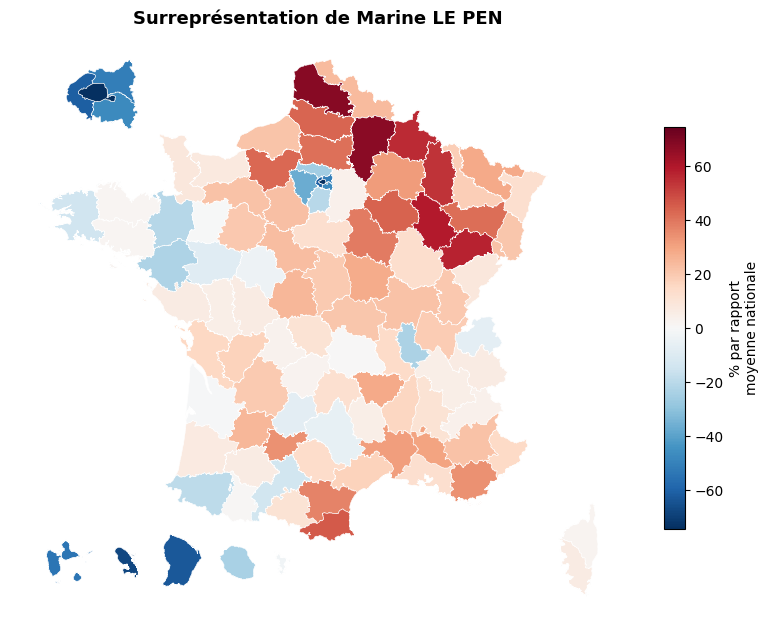

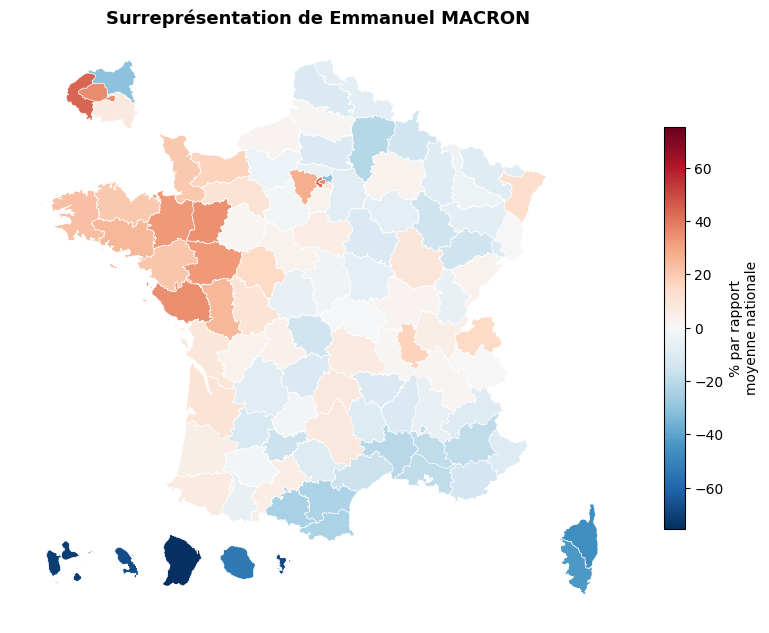

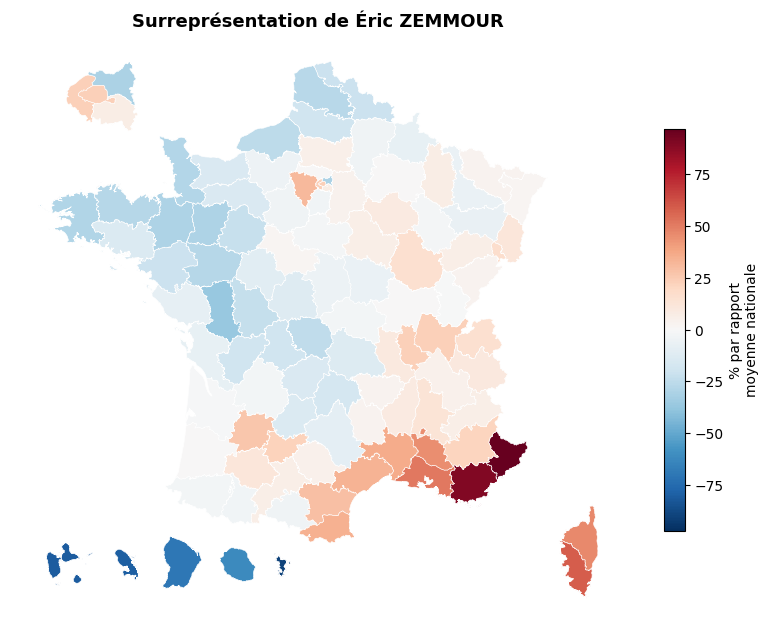

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from cartiflette import carti_download



# Reconstruction de score_departements
df["code_commune"] = df["code_departement"].astype(str).str.zfill(2) + df["code_commune"].astype(str).str.zfill(3)
df["candidat"] = df["prenom"].astype(str) + " " + df["nom"].astype(str)

non_candidats = ["Abstentions", "Blancs", "Nuls", "Exprimés", "Votants", "Inscrits"]
df_expr = df[~df["nom"].isin(non_candidats)].copy()

# Scores nationaux
votes_nationaux = df_expr.groupby("candidat")["voix"].sum().reset_index()
votes_nationaux.columns = ["candidat", "votes_national"]
total_national = votes_nationaux["votes_national"].sum()
votes_nationaux["score_national"] = votes_nationaux["votes_national"] / total_national * 100

# Scores départementaux
votes_dept = df_expr.groupby(["code_departement", "candidat"])["voix"].sum().reset_index()
votes_dept.columns = ["code_departement", "candidat", "votes_departement"]
total_dept = votes_dept.groupby("code_departement")["votes_departement"].sum().reset_index()
total_dept.columns = ["code_departement", "total_dept"]
votes_dept = votes_dept.merge(total_dept, on="code_departement")
votes_dept["score_departement"] = votes_dept["votes_departement"] / votes_dept["total_dept"] * 100

# Fusion national + départemental + surreprésentation
score_departements = votes_dept.merge(votes_nationaux, on="candidat")
score_departements["surrepresentation"] = (
    (score_departements["score_departement"] - score_departements["score_national"])
    / score_departements["score_national"] * 100
)

#  Fond de carte 
departement_borders = carti_download(
    values=["France"],
    crs=4326,
    borders="DEPARTEMENT",
    vectorfile_format="geojson",
    simplification=50,
    filter_by="FRANCE_ENTIERE_DROM_RAPPROCHES",
    source="EXPRESS-COG-CARTO-TERRITOIRE",
    year=2022
)

# Fonction cartographie 
def carte_candidat(score_departements, candidat, departement_borders):
    df_cand = score_departements[
        score_departements["candidat"] == candidat
    ].copy()

    df_cand["code_departement"] = df_cand["code_departement"].astype(str).str.zfill(2)
    departement_borders["code_departement"] = (
        departement_borders["INSEE_DEP"].astype(str).str.zfill(2)
    )

    gdf = departement_borders.merge(
        df_cand[["code_departement", "surrepresentation"]],
        on="code_departement",
        how="left"
    )

    vmax = gdf["surrepresentation"].abs().max()
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

    fig, ax = plt.subplots(figsize=(8, 7))
    gdf.plot(
        column="surrepresentation",
        cmap="RdBu_r",
        norm=norm,
        linewidth=0.4,
        edgecolor="white",
        ax=ax,
        legend=True,
        legend_kwds={
            "label": "% par rapport\nmoyenne nationale",
            "orientation": "vertical",
            "shrink": 0.6
        }
    )
    ax.set_title(f"Surreprésentation de {candidat}", fontsize=13, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

carte_candidat(score_departements, "Marine LE PEN", departement_borders)
carte_candidat(score_departements, "Emmanuel MACRON", departement_borders)
carte_candidat(score_departements, "Éric ZEMMOUR", departement_borders)